# Log Anomaly Detection (BGL Dataset): Vanilla RAG Baseline

**Experiment:** E03 — Vanilla RAG anomaly detection. No ML training. Pure retrieval-augmented generation.  
**Dataset:** BGL  
**Embedding model:** `BAAI/bge-base-en-v1.5`  
**Generation model:** `llama-3.3-70b-versatile` via Groq API  
**Evaluation model:** `qwen/qwen3-32b` via Groq API (LLM-as-judge)  
**Vector store:** Qdrant (in-memory)  

**Prompts:** Loaded from `src/Prompts/` 

In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
# =============================================================================
import subprocess, sys

def install_packages(pkgs):
    for p in pkgs:
        print(f"Installing: {p}")
        r = subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"],
                           capture_output=True, text=True)
        print("  OK" if r.returncode == 0 else f"  WARN: {r.stderr[:120]}")

install_packages([
    "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
    "groq", "tqdm", "sentence-transformers", "qdrant-client",
])
print("\nAll packages ready.")

Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: groq
  OK
Installing: tqdm
  OK
Installing: sentence-transformers
  OK
Installing: qdrant-client
  OK

All packages ready.


Prompts loaded from : c:\Users\Abhishek Mulay\Desktop\UpgradAIML\Masters\Topics\Revised_Topics\Topic 1\LogSense\Implementation\Experiments\src\Prompts
  Dataset               : BGL
  Embed model           : BAAI/bge-base-en-v1.5
  LLM model             : llama-3.1-8b-instant
  Eval model            : qwen/qwen3-32b
  Test normal cap       : 200
  Test anomaly cap      : 15
  Retrieval K (logs)    : 5
  Retrieval K (knowledge): 2 / collection  [arch + severity + rca + roles]
  Primary Groq keys     : 5  | Fallback keys: 5

Loading BGL structured log ...
  Rows: 2000,  Normal: 1857,  Anomalous: 143
  Sample: [KERNEL] [INFO] instruction cache parity error corrected | Template: instruction cache parity error corrected

Creating test split ...
  Test Normal     : 200  (93.0%)
  Test Anomalous  : 15  (7.0%)
  Test Total      : 215

Connecting to persistent Qdrant KB ...
Collection                Points
----------------------------------
bgl_logs                    3765
bgl_architecture      

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3609.42it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Log hits (5):
    [1] Anomalous  sim=0.9344  [KERNEL] [FATAL] data TLB error interrupt | Template: data TLB error i
    [2] Anomalous  sim=0.9344  [KERNEL] [FATAL] data TLB error interrupt | Template: data TLB error i
    [3] Anomalous  sim=0.9344  [KERNEL] [FATAL] data TLB error interrupt | Template: data TLB error i
    [4] Anomalous  sim=0.9344  [KERNEL] [FATAL] data TLB error interrupt | Template: data TLB error i
    [5] Anomalous  sim=0.9344  [KERNEL] [FATAL] data TLB error interrupt | Template: data TLB error i

  Knowledge hits (10):
    [ARCHITECTURE]  score=0.7745  [Error Types & Details] Kernel error types KERNELKERNDTLB — Data TLB error inter
    [ARCHITECTURE]  score=0.7745  [Error Types & Details] Kernel error types KERNELKERNDTLB — Data TLB error inter
    [RCA]  score=0.7719  [RCA Evidence | BGL-RCA-001] Sustained Hardware Fault - Data TLB Degradation
Log
    [RCA]  score=0.7719  [RCA Evidence | BGL-RCA-001] Sustained Hardware Fault - Data TLB Degradation
Log
    [SE

RAG Inference:  54%|█████▍    | 116/215 [07:52<07:42,  4.67s/it]

  [rate-limit] Worker rotated to fallback key (attempt 1/9)


...


  Inference complete.  Parse errors: 0 / 215

  EFFICIENCY SUMMARY  [BGL]  Vanilla RAG  (n=215)
  Metric                 Retrieval (ms)   LLM Latency (ms)   Generation (ms)    Total (ms)
----------------------------------------------------------------------------------------
  Mean                            741.5            18298.0             359.6       19399.2
  Median                          555.9            19476.9             178.3       20425.9
  p95                            1608.2            27749.6            2896.1       29279.7
  p99                            2640.7            29341.4            3495.0       30214.3
  Min                             404.9              454.2               4.1         941.5
  Max                            2745.7            30627.4            3655.3       31869.1

  STANDARD METRICS  [BGL]  (Vanilla RAG)
  Test set  : 215  (Normal=200, Anomalous=15)
  TP=15  TN=196  FP=4  FN=0
-------------------------------------------------------------

RAG Evaluation:  80%|████████  | 12/15 [15:04<03:43, 74.41s/it]

  [rate-limit] Worker rotated to fallback key (attempt 1/9)


RAG Evaluation: 100%|██████████| 15/15 [18:26<00:00, 73.78s/it]



  RETRIEVAL METRICS  [BGL]  (n=15)
  MRR                   : 1.0000
  Hit Rate @5           : 1.0000
  Context Precision     : 1.0000

  RAGAs METRICS (prompts shared with E02)
  Faithfulness          : 0.5133
  Answer Relevance      : 0.8000
  Context Precision     : 1.0000
  Context Recall        : 1.0000

  ADDITIONAL RAG METRICS
  Root Cause Score      : 0.9700
  Evidence Support      : 0.4733
  Severity Agreement    : 1.0000
  Consistency Score     : 1.0000
  Role Appr. (SRE)      : 0.6600
  Role Appr. (DevOps)   : 0.3800
  Completeness Score    : 0.9333


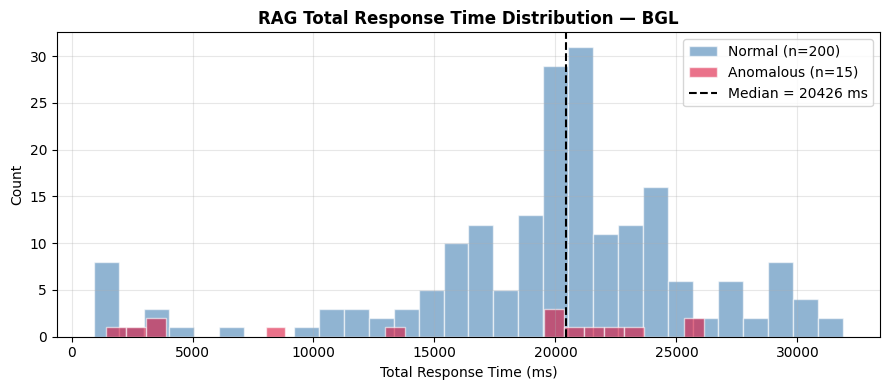

  Saved: bgl_rag_response_time_dist.png


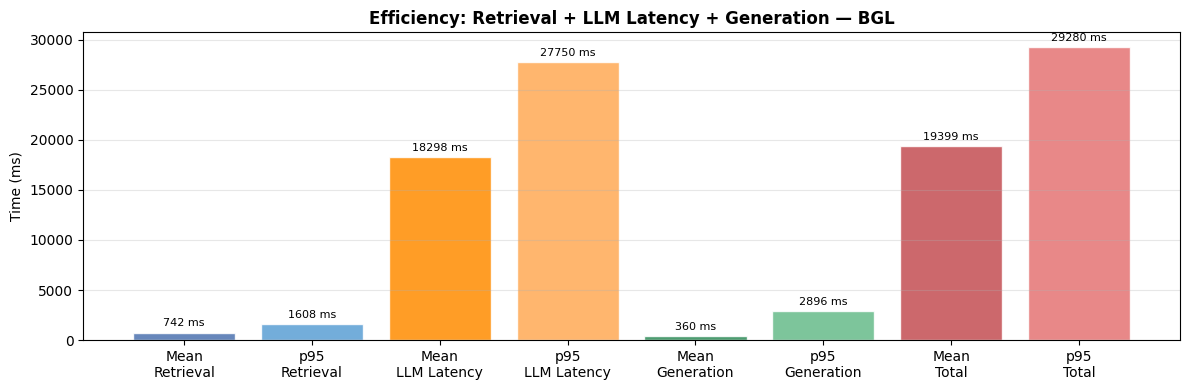

  Saved: bgl_rag_latency_breakdown.png


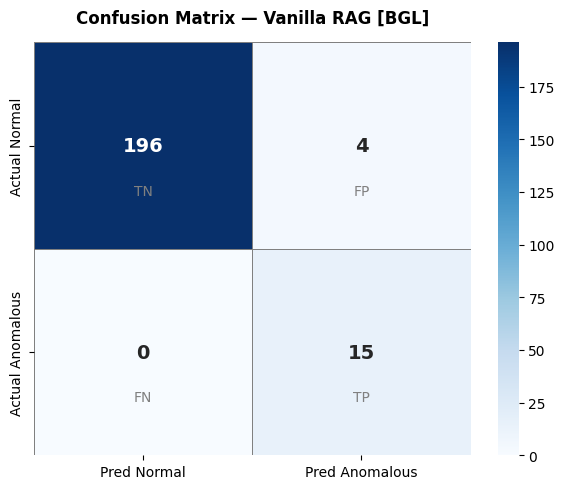

  Saved: bgl_rag_confusion_matrix.png


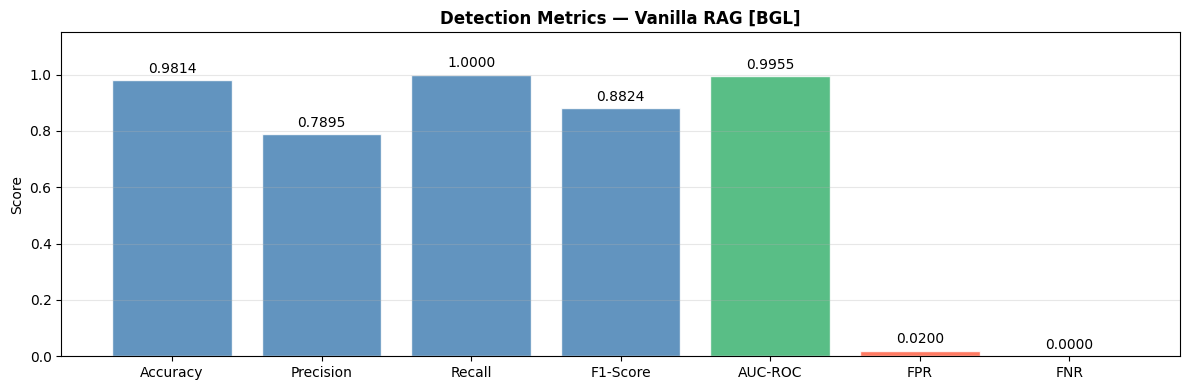

  Saved: bgl_rag_detection_metrics.png


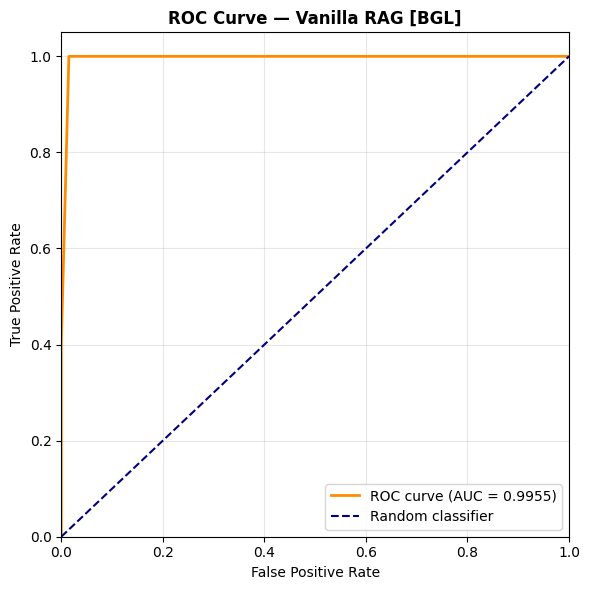

  Saved: bgl_rag_roc_curve.png


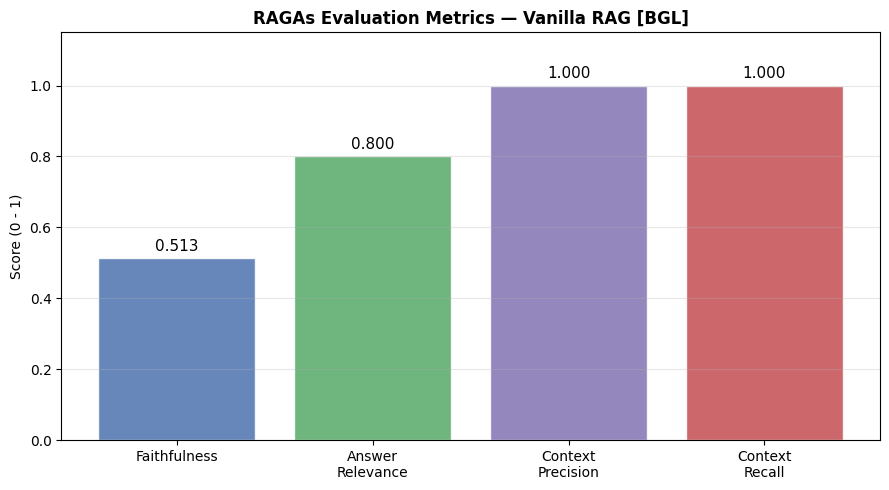

  Saved: bgl_rag_ragas_metrics.png


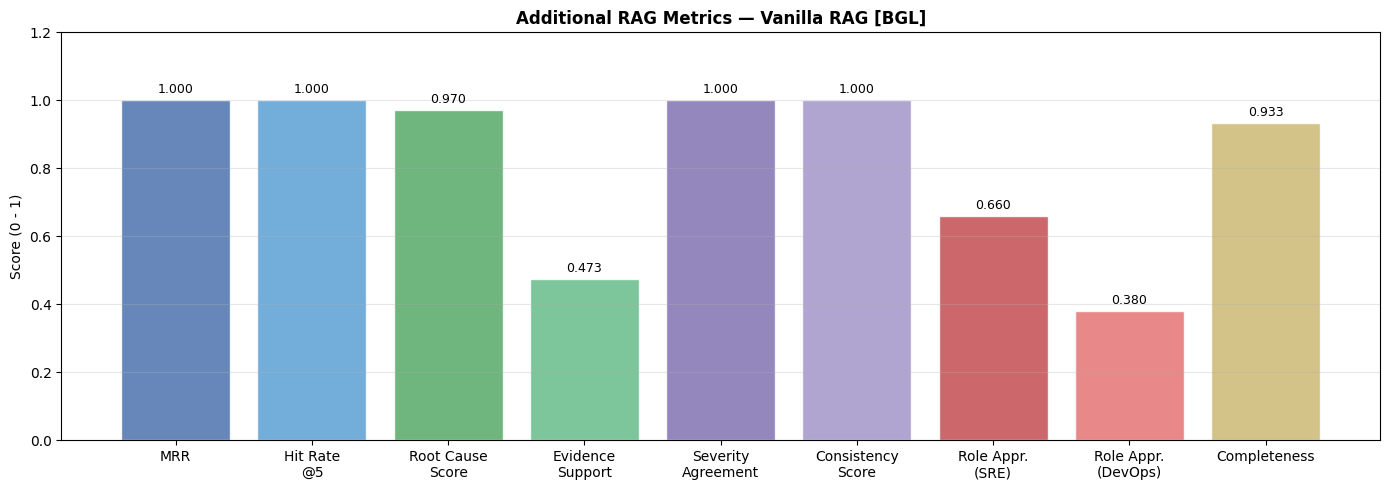

  Saved: bgl_rag_additional_rag_metrics.png


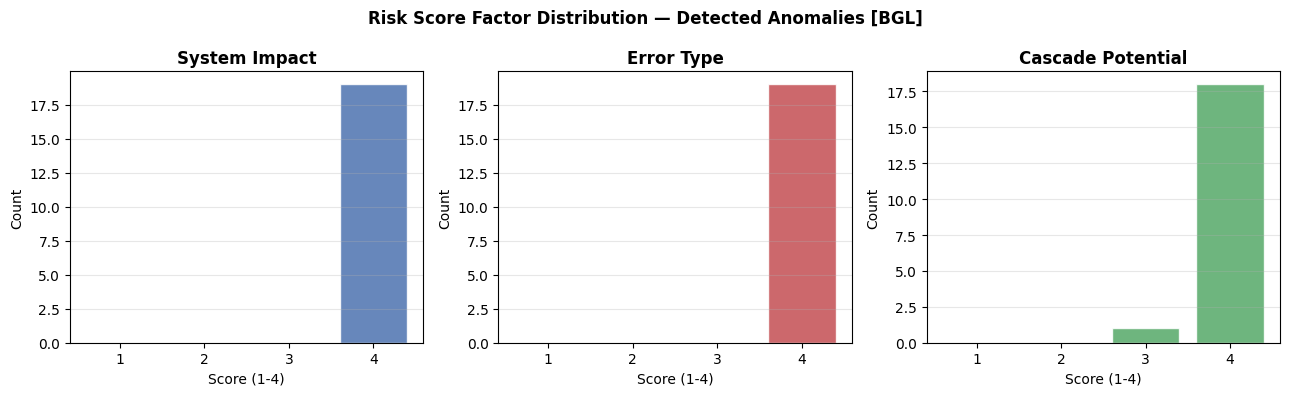

  Saved: bgl_rag_risk_score_dist.png

All visualisations complete.


In [5]:
# =============================================================================
# CELL 2 — IMPORTS, CONFIGURATION, DATA LOADING, KNOWLEDGE BASE,
#           RAG INFERENCE, METRICS, AND VISUALISATION
# =============================================================================

# -- Standard library imports -------------------------------------------------
import json, os, re, sys, time, warnings
from typing import Any, Dict, List, Optional, Tuple

# -- Third-party imports ------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from groq import Groq
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

# -- Persistent KB (src/KnowledgeBase/) ---------------------------------------
_KB_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "KnowledgeBase"))
if _KB_DIR not in sys.path:
    sys.path.insert(0, _KB_DIR)
from kb_utils import KBClient

# -- Shared prompt repository (src/Prompts/) ----------------------------------
_PROMPTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Prompts"))
if _PROMPTS_DIR not in sys.path:
    sys.path.insert(0, _PROMPTS_DIR)

from detection_prompts import (
    BGL_CONFIG,
    build_rag_system_prompt,
    format_retrieved_context,
    build_rag_user_prompt,
)
from eval_prompts import (
    JUDGE_SYSTEM_PROMPT,
    build_faithfulness_prompt,
    build_answer_relevance_prompt,
    build_sre_appropriateness_prompt,
    build_devops_appropriateness_prompt,
    build_context_recall_prompt,
    build_root_cause_score_prompt,
    build_evidence_support_prompt,
    build_completeness_prompt_rag,
)
print(f"Prompts loaded from : {_PROMPTS_DIR}")
RAG_SYSTEM_PROMPT = build_rag_system_prompt(BGL_CONFIG)

# =============================================================================
# SECTION 1 — CONFIGURATION
# =============================================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATASET = "BGL"

# Models
EMBED_MODEL_NAME = "BAAI/bge-base-en-v1.5"
LLM_MODEL        = "llama-3.1-8b-instant"
EVAL_MODEL       = "qwen/qwen3-32b"

# Few-shot pool sizes (must match build_kb.py to keep KB/test sets disjoint)
N_FEW_SHOT_NORMAL = 5
N_FEW_SHOT_ANOM   = 5

# Test set — mirrors BGL real-world ~7% anomaly rate
TEST_NORMAL_CAP  = 200
TEST_ANOMALY_CAP = 15

# Retrieval
RETRIEVAL_K           = 5   # similar log examples from bgl_logs
RETRIEVAL_K_KNOWLEDGE = 2   # docs per knowledge collection (architecture, severity, rca, roles)

# API config
MAX_RETRIES     = 3
RETRY_DELAY_S   = 5
REQUEST_DELAY_S = 0.5
LLM_MAX_TOKENS  = 900
LLM_TEMPERATURE = 0.0
# qwen3-32b emits <think>...</think> before JSON — 1024 tokens covers thinking trace + JSON
EVAL_MAX_TOKENS = 1024

# -- Groq API keys — groq_key_1.txt…groq_key_5.txt (primary, one per worker)
#                    groq_key_6.txt…groq_key_10.txt (fallback on rate-limit) -
def _load_groq_key(n: int) -> Optional[str]:
    p = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Keys", f"groq_key_{n}.txt"))
    try:
        with open(p) as _f:
            return _f.read().strip()
    except FileNotFoundError:
        return None

_ALL_PRIMARY  = [k for k in [_load_groq_key(i) for i in range(1, 6)]  if k]
_ALL_FALLBACK = [k for k in [_load_groq_key(i) for i in range(6, 11)] if k]

if not _ALL_PRIMARY:
    raise FileNotFoundError(
        "No primary Groq keys found. "
        "Expected src/Keys/groq_key_1.txt … groq_key_5.txt"
    )

GROQ_API_KEY = _ALL_PRIMARY[0]   # kept for any direct references

DATASET_CONFIG = {
    "structured_log_path": "../../../Datasets/BGL/Sample/BGL_2k.log_structured.csv",
    "templates_path":      "../../../Datasets/BGL/Sample/BGL_2k.log_templates.csv",
    "label_col":     "Label",
    "normal_value":  "-",
    "event_id_col":  "EventId",
    "component_col": "Component",
    "level_col":     "Level",
    "content_col":   "Content",
    "template_col":  "EventTemplate",
}

print(f"  Dataset               : {DATASET}")
print(f"  Embed model           : {EMBED_MODEL_NAME}")
print(f"  LLM model             : {LLM_MODEL}")
print(f"  Eval model            : {EVAL_MODEL}")
print(f"  Test normal cap       : {TEST_NORMAL_CAP}")
print(f"  Test anomaly cap      : {TEST_ANOMALY_CAP}")
print(f"  Retrieval K (logs)    : {RETRIEVAL_K}")
print(f"  Retrieval K (knowledge): {RETRIEVAL_K_KNOWLEDGE} / collection  [arch + severity + rca + roles]")
print(f"  Primary Groq keys     : {len(_ALL_PRIMARY)}  | Fallback keys: {len(_ALL_FALLBACK)}")

# =============================================================================
# SECTION 2 — DATA LOADING
# =============================================================================
def build_log_text(row: pd.Series) -> str:
    comp = str(row.get("Component", "")).strip()
    lvl  = str(row.get("Level", "")).strip()
    cont = str(row.get("Content", "")).strip()
    tmpl = str(row.get("EventTemplate", "")).strip()
    return f"[{comp}] [{lvl}] {cont} | Template: {tmpl}"

def load_bgl(config: Dict) -> pd.DataFrame:
    print("\nLoading BGL structured log ...")
    df_logs = pd.read_csv(config["structured_log_path"])
    df_tmpl = pd.read_csv(config["templates_path"])
    df = df_logs.merge(df_tmpl, on=config["event_id_col"], how="left", suffixes=("", "_tmpl"))
    df["is_normal"]    = df[config["label_col"]] == config["normal_value"]
    df["binary_label"] = (~df["is_normal"]).astype(int)
    df["log_text"]     = df.apply(build_log_text, axis=1)
    n_norm = int(df["is_normal"].sum())
    n_anom = int((~df["is_normal"]).sum())
    print(f"  Rows: {len(df)},  Normal: {n_norm},  Anomalous: {n_anom}")
    print(f"  Sample: {df['log_text'].iloc[0]}")
    return df

df = load_bgl(DATASET_CONFIG)

# =============================================================================
# SECTION 3 — TEST SPLIT
#
# Mirrors the exact split used in build_kb.py and E02 so all experiments
# evaluate on the same held-out test set (no overlap with the persistent KB).
# =============================================================================
def create_test_split(
    df: pd.DataFrame,
    n_few_shot_normal: int,
    n_few_shot_anom: int,
    test_normal_cap: int,
    test_anomaly_cap: int,
    seed: int = 42,
) -> pd.DataFrame:
    df_n = df[df["is_normal"]].sample(frac=1, random_state=seed).reset_index(drop=True)
    df_a = df[~df["is_normal"]].sample(frac=1, random_state=seed).reset_index(drop=True)

    # Skip the same few-shot rows excluded from the persistent KB
    rem_n = df_n.iloc[n_few_shot_normal:].reset_index(drop=True)
    rem_a = df_a.iloc[n_few_shot_anom:].reset_index(drop=True)

    n_t_n = min(test_normal_cap,  len(rem_n))
    n_t_a = min(test_anomaly_cap, len(rem_a))
    if n_t_a < test_anomaly_cap:
        print(f"  WARNING: only {n_t_a} anomalies available (requested {test_anomaly_cap}).")

    return (
        pd.concat([rem_n.iloc[:n_t_n], rem_a.iloc[:n_t_a]], ignore_index=True)
        .sample(frac=1, random_state=seed).reset_index(drop=True)
    )

print("\nCreating test split ...")
test_df = create_test_split(
    df, N_FEW_SHOT_NORMAL, N_FEW_SHOT_ANOM,
    TEST_NORMAL_CAP, TEST_ANOMALY_CAP, RANDOM_SEED,
)

n_tn = int(test_df["is_normal"].sum())
n_ta = int((~test_df["is_normal"]).sum())
print(f"  Test Normal     : {n_tn}  ({n_tn/len(test_df)*100:.1f}%)")
print(f"  Test Anomalous  : {n_ta}  ({n_ta/len(test_df)*100:.1f}%)")
print(f"  Test Total      : {len(test_df)}")

# =============================================================================
# SECTION 4 — PERSISTENT KNOWLEDGE BASE CLIENT
#
# Connects to the shared Qdrant KB built by src/KnowledgeBase/build_kb.py.
# All RAG variants use the same KB for a fair comparison — no per-notebook
# KB construction or embedding at runtime.
# =============================================================================
print("\nConnecting to persistent Qdrant KB ...")
kb = KBClient()
kb.collection_stats()
print("  KB client ready")

# =============================================================================
# SECTION 5 — MULTI-COLLECTION RETRIEVAL (via persistent KB)
#
# Retrieves from six collections per query:
#   bgl_logs         — similar log examples (classification signal + retrieval metrics)
#   bgl_architecture — system architecture context (grounds RCA in system knowledge)
#   bgl_severity     — RAS severity taxonomy (calibrates risk assessment)
#   bgl_rca          — root cause analysis examples (provides causal chain patterns)
#   role_sre         — SRE on-call reference guide (actionable SRE remediation)
#   role_devops      — DevOps engineer reference guide (infrastructure remediation)
#
# log_hits and knowledge_hits are kept separate:
#   log_hits       — passed to the LLM AND used for label-based retrieval metrics
#                    (MRR, Hit Rate@K, Context Precision)
#   knowledge_hits — passed to the LLM for contextual enrichment only; not used
#                    for label-based metrics since they carry no binary label
# =============================================================================

def _format_knowledge_context(knowledge_hits: List[Dict]) -> str:
    """Format architecture, severity, RCA, and role guide hits for injection into the user prompt."""
    if not knowledge_hits:
        return "(none)"
    lines = []
    for h in knowledge_hits:
        cat     = h.get("category", "").upper()
        section = h.get("section", "")
        label   = f" | {section}" if section else ""
        text    = h["text"][:400]
        lines.append(f"[{cat}{label} | score={h['score']:.3f}]\n{text}")
    return "\n\n".join(lines)


def _build_multi_user_prompt(log_text: str, log_hits: List[Dict], knowledge_hits: List[Dict]) -> str:
    """
    Build the RAG user prompt with two distinct context sections:
      1. Similar log examples  — for classification signal (label + similarity)
      2. System knowledge      — architecture, severity taxonomy, RCA examples, role guides
    """
    log_ctx   = format_retrieved_context(log_hits) if log_hits else "(none)"
    know_ctx  = _format_knowledge_context(knowledge_hits)
    return (
        f"Log entry to analyze:\n{log_text}\n\n"
        f"Similar log examples from knowledge base:\n{log_ctx}\n\n"
        f"System knowledge context (architecture, severity taxonomy, RCA examples, role guides):\n{know_ctx}"
    )


def retrieve(query_text: str) -> Tuple[List[Dict], List[Dict]]:
    """
    Query the persistent KB across six collections.

    Returns
    -------
    log_hits       : List[Dict] — top-RETRIEVAL_K results from bgl_logs
    knowledge_hits : List[Dict] — top-RETRIEVAL_K_KNOWLEDGE results each from
                                  bgl_architecture, bgl_severity, bgl_rca,
                                  role_sre, role_devops — merged and ranked by score
    """
    # Log hits — classification signal and label-based retrieval metrics
    raw_logs = kb.query_bgl_logs(query_text, top_k=RETRIEVAL_K)
    log_hits = [
        {
            "log_text":     h["text"],
            "label":        h["label"],
            "binary_label": 0 if h["label"] == "Normal" else 1,
            "score":        h["score"],
            "rank":         idx + 1,
        }
        for idx, h in enumerate(raw_logs)
    ]

    # Knowledge hits — architecture, severity, RCA, and role guides (merged, ranked by score)
    raw_knowledge = kb.query_multi(
        ["bgl_architecture", "bgl_severity", "bgl_rca", "role_sre", "role_devops"],
        query_text,
        top_k_per_collection=RETRIEVAL_K_KNOWLEDGE,
    )
    knowledge_hits = [
        {
            "text":     h["text"],
            "category": h.get("category", ""),
            "section":  h.get("section", "") or h.get("rca_section", ""),
            "score":    h["score"],
        }
        for h in raw_knowledge
    ]

    return log_hits, knowledge_hits


# Sanity check
print(f"\nRetrieval sanity check  (logs k={RETRIEVAL_K}, knowledge k={RETRIEVAL_K_KNOWLEDGE}/collection) ...")
_q = test_df.iloc[0]["log_text"]
print(f"  Query : {_q[:90]}")
_log_hits, _know_hits = retrieve(_q)
print(f"\n  Log hits ({len(_log_hits)}):")
for r in _log_hits:
    print(f"    [{r['rank']}] {r['label']:9s}  sim={r['score']:.4f}  {r['log_text'][:70]}")
print(f"\n  Knowledge hits ({len(_know_hits)}):")
for h in _know_hits:
    print(f"    [{h['category'].upper()}]  score={h['score']:.4f}  {h['text'][:80]}")

# =============================================================================
# SECTION 7 — GROQ CLIENT AND API HELPERS
# =============================================================================
import threading

# --- Parallel key pool: thread-local primary key + shared fallback pool -----
N_PARALLEL_WORKERS = min(5, len(_ALL_PRIMARY))

_fallback_lock = threading.Lock()
_fallback_pool = list(_ALL_FALLBACK)   # each fallback key is consumed once

_worker_key  = threading.local()       # per-thread current Groq API key
_assign_lock = threading.Lock()
_assign_idx  = [0]                     # monotonic counter shared across threads


def _init_worker_key() -> None:
    """Assign a unique primary key to this thread on its first API call.
    Staggers worker startup by 1s each to avoid simultaneous rate-limit spikes."""
    if not hasattr(_worker_key, "current"):
        with _assign_lock:
            idx = _assign_idx[0] % len(_ALL_PRIMARY)
            stagger = _assign_idx[0]
            _assign_idx[0] += 1
        time.sleep(stagger * 1.0)          # stagger: worker-0=0s, 1=1s, 2=2s ...
        _worker_key.current = _ALL_PRIMARY[idx]


def _rotate_to_fallback() -> bool:
    """Switch this worker's key to the next available fallback key.
    Returns True if a fallback key was available, False if pool is exhausted."""
    with _fallback_lock:
        if _fallback_pool:
            _worker_key.current = _fallback_pool.pop(0)
            return True
    return False


def _is_rate_limit(exc: Exception) -> bool:
    s = type(exc).__name__ + " " + str(exc)
    return "ratelimit" in s.lower() or "rate_limit" in s.lower() or "429" in s

print(f"  Parallel workers : {N_PARALLEL_WORKERS}")
print(f"  Primary keys     : {len(_ALL_PRIMARY)}  | Fallback keys: {len(_ALL_FALLBACK)}")


def call_groq(
    system_prompt: str,
    user_message: str,
    model: str,
    max_tokens: int = LLM_MAX_TOKENS,
    temperature: float = LLM_TEMPERATURE,
) -> Tuple[Optional[str], float, float]:
    """Call Groq with thread-local key; auto-rotates to fallback on rate limit.
    Returns (raw_text, latency_ms, generation_ms)."""
    _init_worker_key()
    budget = MAX_RETRIES + len(_ALL_FALLBACK) + 1
    for attempt in range(budget):
        try:
            client = Groq(api_key=_worker_key.current)
            t0     = time.perf_counter()
            resp   = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_message},
                ],
                max_tokens=max_tokens,
                temperature=temperature,
            )
            t1     = time.perf_counter()
            total  = (t1 - t0) * 1000.0
            usage  = resp.usage
            c_tok  = usage.completion_tokens if usage else 1
            p_tok  = usage.prompt_tokens     if usage else 0
            gen_ms = total * (c_tok / ((p_tok + c_tok) or 1))
            return resp.choices[0].message.content.strip(), total - gen_ms, gen_ms
        except Exception as e:
            if _is_rate_limit(e):
                if _rotate_to_fallback():
                    print(f"  [rate-limit] Worker rotated to fallback key (attempt {attempt+1}/{budget})", flush=True)
                    continue                   # retry immediately with new key
                print(f"  [rate-limit] All keys exhausted — sleeping 60s (attempt {attempt+1}/{budget})", flush=True)
                time.sleep(60)
            else:
                time.sleep(RETRY_DELAY_S * min(attempt + 1, 5))
    print(f"  [call-groq] All {budget} attempts failed — returning None", flush=True)
    return None, 0.0, 0.0

def _strip_thinking(raw: str) -> str:
    """Remove <think>...</think> blocks emitted by qwen3 reasoning model."""
    stripped = re.sub(r'<think>.*?</think>', '', raw, flags=re.DOTALL).strip()
    return stripped if stripped else raw

# =============================================================================
# SECTION 8 — RESPONSE PARSER
#
# Risk Score formula (applied programmatically — not trusted from LLM output):
#   total = (system_impact x 0.4) + (error_type x 0.3) + (cascade_potential x 0.2)
# =============================================================================
def _compute_risk(si: Any, et: Any, cp: Any) -> Dict:
    si  = max(1, min(4, int(si)))
    et  = max(1, min(4, int(et)))
    cp  = max(1, min(4, int(cp)))
    tot = round(si * 0.4 + et * 0.3 + cp * 0.2, 3)
    lvl = "High" if tot >= 2.8 else ("Medium" if tot >= 1.8 else "Low")
    return {"system_impact": si, "error_type": et, "cascade_potential": cp,
            "total_score": tot, "risk_level": lvl}

def parse_rag_response(raw: Optional[str]) -> Dict:
    default = {
        "label": "Normal", "confidence": 0.5, "anomaly_explanation": "",
        "rca_summary": "", "rca_detailed": "", "rca_confidence_level": "",
        "rca_confidence_reasoning": "", "rca_causal_chain": [],
        "rca_supporting_evidence": [],
        "risk_system_impact": 0, "risk_error_type": 0, "risk_cascade_potential": 0,
        "risk_total_score": 0.0, "risk_level": "",
        "sre_action": "", "devops_action": "", "parse_error": True,
    }
    if raw is None:
        return default.copy()
    try:
        cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")
        m = re.search(r'\{.*\}', cleaned, re.DOTALL)
        if m:
            p = json.loads(m.group())
            r = default.copy()
            r["parse_error"] = False
            r["label"]       = str(p.get("label", "Normal"))
            r["confidence"]  = float(max(0.0, min(1.0, float(p.get("confidence", 0.5)))))
            if r["label"] == "Anomalous":
                r["anomaly_explanation"]       = str(p.get("anomaly_explanation", ""))
                rca = p.get("rca", {})
                r["rca_summary"]               = str(rca.get("summary", ""))
                r["rca_detailed"]              = str(rca.get("detailed_description", ""))
                r["rca_confidence_level"]      = str(rca.get("confidence_level", ""))
                r["rca_confidence_reasoning"]  = str(rca.get("confidence_reasoning", ""))
                r["rca_causal_chain"]          = list(rca.get("causal_chain", []))
                r["rca_supporting_evidence"]   = list(rca.get("supporting_evidence", []))
                rs  = p.get("risk_score", {})
                crs = _compute_risk(
                    rs.get("system_impact", 2),
                    rs.get("error_type", 2),
                    rs.get("cascade_potential", 2),
                )
                r["risk_system_impact"]     = crs["system_impact"]
                r["risk_error_type"]        = crs["error_type"]
                r["risk_cascade_potential"] = crs["cascade_potential"]
                r["risk_total_score"]       = crs["total_score"]
                r["risk_level"]             = crs["risk_level"]
                rem = p.get("remediation", {})
                r["sre_action"]    = str(rem.get("sre_action", ""))
                r["devops_action"] = str(rem.get("devops_action", ""))
            return r
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    return default.copy()

# =============================================================================
# SECTION 9 — RAG INFERENCE ON TEST SET
# =============================================================================
print(f"\nRunning parallel Vanilla RAG inference on {len(test_df)} test samples ...")
print(f"  Retrieval K (logs)     : {RETRIEVAL_K}")
print(f"  Retrieval K (knowledge): {RETRIEVAL_K_KNOWLEDGE} / collection")
print(f"  LLM model              : {LLM_MODEL}")
print(f"  Workers                : {N_PARALLEL_WORKERS}\n")


def _run_rag_inference(row_dict: dict) -> dict:
    t_ret0 = time.perf_counter()
    log_hits, knowledge_hits = retrieve(row_dict["log_text"])
    ret_ms = (time.perf_counter() - t_ret0) * 1000.0
    raw, l_ms, g_ms = call_groq(
        RAG_SYSTEM_PROMPT,
        _build_multi_user_prompt(row_dict["log_text"], log_hits, knowledge_hits),
        LLM_MODEL,
    )
    parsed                   = parse_rag_response(raw)
    parsed["true_label"]     = int(row_dict["binary_label"])
    parsed["log_text"]       = row_dict["log_text"]
    parsed["raw_response"]   = raw
    parsed["retrieved_docs"] = log_hits        # label-based retrieval metrics (MRR, Hit Rate, Precision)
    parsed["knowledge_docs"] = knowledge_hits  # architecture + severity + RCA + role context
    parsed["retrieval_ms"]   = ret_ms
    parsed["latency_ms"]     = l_ms
    parsed["generation_ms"]  = g_ms
    return parsed


rows = test_df.to_dict("records")
results: List[Dict] = [None] * len(rows)

with ThreadPoolExecutor(max_workers=N_PARALLEL_WORKERS) as executor:
    future_to_idx = {
        executor.submit(_run_rag_inference, row): idx
        for idx, row in enumerate(rows)
    }
    for future in tqdm(as_completed(future_to_idx), total=len(rows), desc="RAG Inference"):
        idx = future_to_idx[future]
        try:
            results[idx] = future.result()
        except Exception as exc:
            print(f"  Worker error on row {idx}: {exc}")
            results[idx] = {
                "true_label": int(rows[idx]["binary_label"]),
                "log_text": rows[idx]["log_text"],
                "label": "Normal", "confidence": 0.5,
                "parse_error": True, "raw_response": None,
                "retrieved_docs": [],
                "knowledge_docs": [],
                "retrieval_ms": 0.0, "latency_ms": 0.0, "generation_ms": 0.0,
            }

results_df = pd.DataFrame(results)
results_df["pred_label"] = results_df["label"].apply(
    lambda x: 1 if str(x).strip().lower() == "anomalous" else 0
)
print(f"\n  Inference complete.  Parse errors: {int(results_df['parse_error'].sum())} / {len(results_df)}")

# =============================================================================
# SECTION 10 — EFFICIENCY SUMMARY (RETRIEVAL + LLM LATENCY + GENERATION)
# =============================================================================
ret_arr = results_df["retrieval_ms"].values
lat_arr = results_df["latency_ms"].values
gen_arr = results_df["generation_ms"].values
tot_arr = ret_arr + lat_arr + gen_arr

print("\n" + "=" * 82)
print(f"  EFFICIENCY SUMMARY  [{DATASET}]  Vanilla RAG  (n={len(results_df)})")
print("=" * 82)
print(f"  {'Metric':<20}  {'Retrieval (ms)':>15}  {'LLM Latency (ms)':>17}  "
      f"{'Generation (ms)':>16}  {'Total (ms)':>12}")
print("-" * 88)
_stat_fns = {
    "Mean":   np.mean, "Median": np.median,
    "p95":    lambda x: np.percentile(x, 95),
    "p99":    lambda x: np.percentile(x, 99),
    "Min":    np.min,  "Max":    np.max,
}
for lbl, fn in _stat_fns.items():
    print(f"  {lbl:<20}  {fn(ret_arr):>15.1f}  {fn(lat_arr):>17.1f}  "
          f"{fn(gen_arr):>16.1f}  {fn(tot_arr):>12.1f}")
print("=" * 82)

latency_summary = {
    "mean_retrieval_ms":  float(ret_arr.mean()),
    "p95_retrieval_ms":   float(np.percentile(ret_arr, 95)),
    "mean_latency_ms":    float(lat_arr.mean()),
    "p95_latency_ms":     float(np.percentile(lat_arr, 95)),
    "mean_generation_ms": float(gen_arr.mean()),
    "p95_generation_ms":  float(np.percentile(gen_arr, 95)),
    "mean_total_ms":      float(tot_arr.mean()),
    "p95_total_ms":       float(np.percentile(tot_arr, 95)),
}

# =============================================================================
# SECTION 11 — STANDARD ANOMALY DETECTION METRICS
# (Accuracy, Precision, Recall, F1, FPR, FNR, AUC-ROC)
# =============================================================================
y_true   = results_df["true_label"].tolist()
y_pred   = results_df["pred_label"].tolist()
y_scores = [
    c if lbl == "Anomalous" else 1.0 - c
    for c, lbl in zip(results_df["confidence"], results_df["label"])
]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
cm   = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0.0
try:
    auc = roc_auc_score(y_true, y_scores)
except ValueError:
    auc = float("nan")
fpr_curve, tpr_curve, _ = roc_curve(y_true, y_scores)

n_pos, n_neg = y_true.count(1), y_true.count(0)
print("\n" + "=" * 64)
print(f"  STANDARD METRICS  [{DATASET}]  (Vanilla RAG)")
print("=" * 64)
print(f"  Test set  : {len(y_true)}  (Normal={n_neg}, Anomalous={n_pos})")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print("-" * 64)
print(f"  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  FPR        : {fpr_val:.4f}")
print(f"  FNR        : {fnr_val:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print("=" * 64)

std_metrics = dict(
    accuracy=acc, precision=prec, recall=rec, f1=f1,
    tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn), cm=cm,
    fpr=fpr_val, fnr=fnr_val, auc_roc=auc,
    fpr_curve=fpr_curve, tpr_curve=tpr_curve,
)

# =============================================================================
# SECTION 12 — RAG EVALUATION METRICS (TRUE ANOMALIES ONLY)
#
# RAGAs (judge via qwen3-32b):
#   Faithfulness, Answer Relevance, Context Precision, Context Recall
#
# Additional RAG metrics:
#   MRR, Hit Rate@K           — computed from retrieval label matches (log_hits only)
#   Root Cause Score          — judge: RCA technical quality
#   Evidence Support Score    — judge: supporting evidence grounded in log
#   Severity Agreement        — computed: predicted risk_level vs log severity
#   Consistency Score         — computed: risk score variance within same-template groups
#   Role Appropriateness SRE  — judge: sre_action (shared prompt with E02)
#   Role Appropriateness DevOps — judge: devops_action (shared prompt with E02)
#   Completeness Score        — judge: all 10 required output fields present
#
# Note on ctx_text for Context Recall:
#   Passes the full multi-collection context (log examples + architecture +
#   severity + RCA + role guides) so the judge can assess whether the retrieved
#   knowledge is sufficient to derive the RCA — not just the log examples alone.
# =============================================================================

def score_with_judge(prompt: str) -> Tuple[float, str]:
    raw, _, _ = call_groq(JUDGE_SYSTEM_PROMPT, prompt, EVAL_MODEL,
                          max_tokens=EVAL_MAX_TOKENS, temperature=0.0)
    if raw is None:
        return 0.0, "API error"
    content = _strip_thinking(raw)
    try:
        c = re.sub(r"```(?:json)?\s*", "", content).strip().rstrip("`")
        m = re.search(r'\{.*\}', c, re.DOTALL)
        if m:
            p = json.loads(m.group())
            return max(0.0, min(1.0, float(p.get("score", 0.0)))), str(p.get("reason", ""))
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    nums = re.findall(r'\b0\.\d+\b|\b1\.0\b|\b[01]\b', content)
    if nums:
        return max(0.0, min(1.0, float(nums[0]))), content[:80]
    return 0.0, "Parse error"

# ---- Computed retrieval metrics (no judge needed) --------------------------
def _mrr(retrieved: List[Dict], true_label: int) -> float:
    for d in retrieved:
        if d["binary_label"] == true_label:
            return 1.0 / d["rank"]
    return 0.0

def _hit_at_k(retrieved: List[Dict], true_label: int) -> float:
    return 1.0 if any(d["binary_label"] == true_label for d in retrieved) else 0.0

def _context_precision(retrieved: List[Dict], true_label: int) -> float:
    if not retrieved:
        return 0.0
    return sum(1 for d in retrieved if d["binary_label"] == true_label) / len(retrieved)

def _expected_severity(log_text: str) -> str:
    if "[FATAL]" in log_text:
        return "High"
    if "[ERROR]" in log_text:
        return "Medium"
    return "Low"

def _consistency_score(anom_df: pd.DataFrame) -> float:
    """1 - normalised std of risk_total_score within same-template groups."""
    if len(anom_df) < 2:
        return 1.0
    tmp = anom_df.copy()
    tmp["tmpl"] = tmp["log_text"].str.extract(r'Template:\s*(.+)$')
    stds = tmp.groupby("tmpl")["risk_total_score"].std(ddof=0).fillna(0.0)
    return float((1.0 - (stds / 1.35).clip(0.0, 1.0)).mean())

# ---- Evaluation loop (true anomalies only) ---------------------------------
eval_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)
print(f"\nLLM-as-judge on {len(eval_df)} true anomalies  (judge: {EVAL_MODEL}) ...\n")

retrieval_rows, ragas_rows, extra_rows = [], [], []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="RAG Evaluation"):
    retrieved      = row["retrieved_docs"] if isinstance(row["retrieved_docs"], list) else []
    knowledge_docs = row["knowledge_docs"]  if isinstance(row.get("knowledge_docs"), list) else []
    true_lbl   = int(row["true_label"])
    log_text   = row["log_text"]
    anon_expl  = str(row.get("anomaly_explanation", ""))
    rca_sum    = str(row.get("rca_summary", ""))
    rca_det    = str(row.get("rca_detailed", ""))
    rca_cl     = str(row.get("rca_confidence_level", ""))
    rca_cr     = str(row.get("rca_confidence_reasoning", ""))
    causal_ch  = row.get("rca_causal_chain", [])
    supp_ev    = row.get("rca_supporting_evidence", [])
    risk_tot   = float(row.get("risk_total_score", 0.0))
    risk_lvl   = str(row.get("risk_level", ""))
    sre_act    = str(row.get("sre_action", ""))
    dev_act    = str(row.get("devops_action", ""))

    # Full context string for context recall — includes log examples AND all knowledge docs
    ctx_text = (
        "Similar logs:\n" + (format_retrieved_context(retrieved) if retrieved else "(none)") +
        "\n\nSystem knowledge context:\n" + (_format_knowledge_context(knowledge_docs) if knowledge_docs else "(none)")
    )

    # Computed retrieval metrics — label-based, log_hits only
    cp_s = _context_precision(retrieved, true_lbl)
    retrieval_rows.append({
        "mrr":               _mrr(retrieved, true_lbl),
        "hit_at_k":          _hit_at_k(retrieved, true_lbl),
        "context_precision": cp_s,
    })
    time.sleep(REQUEST_DELAY_S)

    # RAGAs (judge-based) — prompts from shared eval_prompts.py
    faith_s, _   = score_with_judge(
        build_faithfulness_prompt(log_text, rca_sum, supp_ev))
    time.sleep(REQUEST_DELAY_S)
    relev_s, _   = score_with_judge(
        build_answer_relevance_prompt(log_text, anon_expl, rca_sum))
    time.sleep(REQUEST_DELAY_S)
    ctx_rec_s, _ = score_with_judge(
        build_context_recall_prompt(log_text, ctx_text, rca_sum))
    time.sleep(REQUEST_DELAY_S)
    ragas_rows.append({
        "faithfulness":      faith_s,
        "answer_relevance":  relev_s,
        "context_precision": cp_s,
        "context_recall":    ctx_rec_s,
    })

    # Additional RAG metrics — judge + computed
    rcs_s,  _ = score_with_judge(
        build_root_cause_score_prompt(log_text, rca_sum, rca_det, causal_ch))
    time.sleep(REQUEST_DELAY_S)
    evid_s, _ = score_with_judge(
        build_evidence_support_prompt(log_text, supp_ev))
    time.sleep(REQUEST_DELAY_S)
    sre_s,  _ = score_with_judge(
        build_sre_appropriateness_prompt(sre_act, log_text))
    time.sleep(REQUEST_DELAY_S)
    dev_s,  _ = score_with_judge(
        build_devops_appropriateness_prompt(dev_act, log_text))
    time.sleep(REQUEST_DELAY_S)
    comp_s, _ = score_with_judge(
        build_completeness_prompt_rag(
            anon_expl, rca_sum, rca_det, rca_cl, rca_cr,
            causal_ch, supp_ev, risk_tot, sre_act, dev_act,
        ))
    time.sleep(REQUEST_DELAY_S)
    extra_rows.append({
        "root_cause_score":            rcs_s,
        "evidence_support_score":      evid_s,
        "severity_agreement":          1.0 if risk_lvl == _expected_severity(log_text) else 0.0,
        "consistency_score":           0.0,   # filled after loop
        "role_appropriateness_sre":    sre_s,
        "role_appropriateness_devops": dev_s,
        "completeness_score":          comp_s,
    })

# Consistency: single value computed across all anomaly results
cons_score = _consistency_score(eval_df)
for e in extra_rows:
    e["consistency_score"] = cons_score

ret_df   = pd.DataFrame(retrieval_rows)
ragas_df = pd.DataFrame(ragas_rows)
extra_df = pd.DataFrame(extra_rows)
mr_ret   = ret_df.mean()
mr_rag   = ragas_df.mean()
mr_ext   = extra_df.mean()

print("\n" + "=" * 64)
print(f"  RETRIEVAL METRICS  [{DATASET}]  (n={len(eval_df)})")
print("=" * 64)
print(f"  MRR                   : {mr_ret['mrr']:.4f}")
print(f"  Hit Rate @{RETRIEVAL_K}           : {mr_ret['hit_at_k']:.4f}")
print(f"  Context Precision     : {mr_ret['context_precision']:.4f}")
print("\n  RAGAs METRICS (prompts shared with E02)")
print("=" * 64)
print(f"  Faithfulness          : {mr_rag['faithfulness']:.4f}")
print(f"  Answer Relevance      : {mr_rag['answer_relevance']:.4f}")
print(f"  Context Precision     : {mr_rag['context_precision']:.4f}")
print(f"  Context Recall        : {mr_rag['context_recall']:.4f}")
print("\n  ADDITIONAL RAG METRICS")
print("=" * 64)
print(f"  Root Cause Score      : {mr_ext['root_cause_score']:.4f}")
print(f"  Evidence Support      : {mr_ext['evidence_support_score']:.4f}")
print(f"  Severity Agreement    : {mr_ext['severity_agreement']:.4f}")
print(f"  Consistency Score     : {mr_ext['consistency_score']:.4f}")
print(f"  Role Appr. (SRE)      : {mr_ext['role_appropriateness_sre']:.4f}")
print(f"  Role Appr. (DevOps)   : {mr_ext['role_appropriateness_devops']:.4f}")
print(f"  Completeness Score    : {mr_ext['completeness_score']:.4f}")
print("=" * 64)

all_metrics = {**std_metrics, **latency_summary}
all_metrics["mrr"]     = float(mr_ret["mrr"])
all_metrics["hit_at_k"]= float(mr_ret["hit_at_k"])
for k, v in {**mr_rag, **mr_ext}.items():
    all_metrics[k] = float(v)

# =============================================================================
# SECTION 13 — VISUALISATIONS
# =============================================================================
PREFIX = "bgl_rag"
y_arr  = np.array(y_true)

# 13a — Response time distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tot_arr[y_arr == 0], bins=30, alpha=0.6, color="steelblue",
        label=f"Normal (n={(y_arr==0).sum()})", edgecolor="white")
ax.hist(tot_arr[y_arr == 1], bins=30, alpha=0.6, color="crimson",
        label=f"Anomalous (n={(y_arr==1).sum()})", edgecolor="white")
ax.axvline(float(np.median(tot_arr)), color="black", linestyle="--", lw=1.5,
           label=f"Median = {np.median(tot_arr):.0f} ms")
ax.set_xlabel("Total Response Time (ms)"); ax.set_ylabel("Count")
ax.set_title(f"RAG Total Response Time Distribution — {DATASET}", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_response_time_dist.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_response_time_dist.png")

# 13b — Latency breakdown bar chart
lat_data = {
    "Mean\nRetrieval":   latency_summary["mean_retrieval_ms"],
    "p95\nRetrieval":    latency_summary["p95_retrieval_ms"],
    "Mean\nLLM Latency": latency_summary["mean_latency_ms"],
    "p95\nLLM Latency":  latency_summary["p95_latency_ms"],
    "Mean\nGeneration":  latency_summary["mean_generation_ms"],
    "p95\nGeneration":   latency_summary["p95_generation_ms"],
    "Mean\nTotal":       latency_summary["mean_total_ms"],
    "p95\nTotal":        latency_summary["p95_total_ms"],
}
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(list(lat_data.keys()), list(lat_data.values()),
              color=["#4C72B0","#5a9fd4","darkorange","#ffaa55",
                     "seagreen","#66bb8a","#C44E52","#e57373"],
              edgecolor="white", alpha=0.85)
ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=8)
ax.set_ylabel("Time (ms)")
ax.set_title(f"Efficiency: Retrieval + LLM Latency + Generation — {DATASET}", fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_latency_breakdown.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_latency_breakdown.png")

# 13c — Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Normal", "Pred Anomalous"],
            yticklabels=["Actual Normal", "Actual Anomalous"],
            linewidths=0.5, linecolor="gray",
            annot_kws={"size": 14, "weight": "bold"}, ax=ax)
for (r, c), lbl in {(0,0):"TN",(0,1):"FP",(1,0):"FN",(1,1):"TP"}.items():
    ax.text(c+0.5, r+0.72, lbl, ha="center", va="center", fontsize=10, color="grey")
ax.set_title(f"Confusion Matrix — Vanilla RAG [{DATASET}]", fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig(f"{PREFIX}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_confusion_matrix.png")

# 13d — Standard detection metrics
det_names  = ["Accuracy","Precision","Recall","F1-Score","AUC-ROC","FPR","FNR"]
det_values = [acc, prec, rec, f1, auc, fpr_val, fnr_val]
det_colours= ["steelblue"]*4 + ["mediumseagreen"] + ["tomato"]*2
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(det_names, det_values, color=det_colours, edgecolor="white", alpha=0.85)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title(f"Detection Metrics — Vanilla RAG [{DATASET}]", fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_detection_metrics.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_detection_metrics.png")

# 13e — ROC curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_curve, tpr_curve, color="darkorange", lw=2,
        label=f"ROC curve (AUC = {auc:.4f})")
ax.plot([0,1],[0,1], color="navy", lw=1.5, linestyle="--", label="Random classifier")
ax.set_xlim([0.0,1.0]); ax.set_ylim([0.0,1.05])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve — Vanilla RAG [{DATASET}]", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_roc_curve.png")

# 13f — RAGAs metrics
fig, ax = plt.subplots(figsize=(9, 5))
ragas_names  = ["Faithfulness","Answer\nRelevance","Context\nPrecision","Context\nRecall"]
ragas_values = [float(mr_rag[k]) for k in
                ["faithfulness","answer_relevance","context_precision","context_recall"]]
bars = ax.bar(ragas_names, ragas_values,
              color=["#4C72B0","#55A868","#8172B2","#C44E52"],
              edgecolor="white", alpha=0.85)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score (0 - 1)")
ax.set_title(f"RAGAs Evaluation Metrics — Vanilla RAG [{DATASET}]", fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_ragas_metrics.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_ragas_metrics.png")

# 13g — Additional RAG metrics
extra_names  = [
    "MRR", f"Hit Rate\n@{RETRIEVAL_K}", "Root Cause\nScore",
    "Evidence\nSupport", "Severity\nAgreement", "Consistency\nScore",
    "Role Appr.\n(SRE)", "Role Appr.\n(DevOps)", "Completeness",
]
extra_values = [
    float(mr_ret["mrr"]), float(mr_ret["hit_at_k"]),
    float(mr_ext["root_cause_score"]), float(mr_ext["evidence_support_score"]),
    float(mr_ext["severity_agreement"]), float(mr_ext["consistency_score"]),
    float(mr_ext["role_appropriateness_sre"]), float(mr_ext["role_appropriateness_devops"]),
    float(mr_ext["completeness_score"]),
]
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(extra_names, extra_values,
              color=["#4C72B0","#5a9fd4","#55A868","#66bb8a",
                     "#8172B2","#a395c9","#C44E52","#e57373","#CCB974"],
              edgecolor="white", alpha=0.85)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylim(0, 1.2); ax.set_ylabel("Score (0 - 1)")
ax.set_title(f"Additional RAG Metrics — Vanilla RAG [{DATASET}]", fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_additional_rag_metrics.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_additional_rag_metrics.png")

# 13h — Risk score factor distribution (detected anomalies)
anom_res = results_df[results_df["pred_label"] == 1]
if len(anom_res) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, col, title, clr in zip(
        axes,
        ["risk_system_impact", "risk_error_type", "risk_cascade_potential"],
        ["System Impact", "Error Type", "Cascade Potential"],
        ["#4C72B0", "#C44E52", "#55A868"],
    ):
        counts = anom_res[col].dropna().value_counts().reindex([1,2,3,4], fill_value=0)
        ax.bar(counts.index.astype(str), counts.values, color=clr, edgecolor="white", alpha=0.85)
        ax.set_xlabel("Score (1-4)"); ax.set_ylabel("Count")
        ax.set_title(title, fontweight="bold"); ax.grid(axis="y", alpha=0.3)
    fig.suptitle(f"Risk Score Factor Distribution — Detected Anomalies [{DATASET}]",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{PREFIX}_risk_score_dist.png", dpi=150, bbox_inches="tight")
    plt.show(); print(f"  Saved: {PREFIX}_risk_score_dist.png")

print("\nAll visualisations complete.")

In [6]:
# =============================================================================
# CELL 3 — ANOMALY OUTPUT INSPECTION
# Prints all generated fields for true anomalies.
# Run after Cell 2 to verify output quality before interpreting evaluation scores.
# =============================================================================
anom_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)
print(f"True anomalies in results: {len(anom_df)}\n")
print("=" * 90)

for i, row in anom_df.iterrows():
    print(f"[{i+1}/{len(anom_df)}]")
    print(f"  Log text            : {row['log_text']}")
    print(f"  Pred label          : {row['label']}  (true=Anomalous)")
    print(f"  Confidence          : {row['confidence']:.3f}")
    print(f"  Parse error         : {row.get('parse_error', False)}")
    print(f"  Anomaly explanation : {row.get('anomaly_explanation', '') or '(empty)'}")
    print(f"  RCA summary         : {row.get('rca_summary', '') or '(empty)'}")
    print(f"  RCA detailed        : {row.get('rca_detailed', '') or '(empty)'}")
    print(f"  Confidence level    : {row.get('rca_confidence_level', '') or '(empty)'}")
    print(f"  Conf. reasoning     : {row.get('rca_confidence_reasoning', '') or '(empty)'}")
    print(f"  Causal chain        : {row.get('rca_causal_chain', [])}")
    print(f"  Supporting evidence : {row.get('rca_supporting_evidence', [])}")
    print(f"  Risk — SI={row.get('risk_system_impact',0)}  "
          f"ET={row.get('risk_error_type',0)}  "
          f"CP={row.get('risk_cascade_potential',0)}  "
          f"Score={row.get('risk_total_score',0.0):.3f}  "
          f"Level={row.get('risk_level','')}")
    print(f"  SRE action          : {row.get('sre_action', '') or '(empty)'}")
    print(f"  DevOps action       : {row.get('devops_action', '') or '(empty)'}")
    print(f"  Retrieval time      : {row.get('retrieval_ms', 0.0):.1f} ms")
    print("-" * 90)

True anomalies in results: 15

[1/15]
  Log text            : [KERNEL] [FATAL] data TLB error interrupt | Template: data TLB error interrupt
  Pred label          : Anomalous  (true=Anomalous)
  Confidence          : 1.000
  Parse error         : False
  Anomaly explanation : The log entry indicates a fatal data TLB error interrupt, which is a hardware fault that can cause a compute node to become unavailable.
  RCA summary         : A sustained hardware fault in the data TLB is causing fatal data TLB error interrupts.
  RCA detailed        : The PowerPC 440 MMU failed to translate a virtual address, resulting in a data TLB error interrupt. This is a hardware fault that can cause a compute node to become unavailable. The TLB is the address-mapping cache inside each CPU core, and its degradation can lead to sustained hardware faults.
  Confidence level    : High
  Conf. reasoning     : The log entry matches a known RCA evidence (BGL-RCA-001) and has a high similarity score with other si